# Apple Global Sales Intelligence Platform

## End-to-End Business Analytics Project

### Project Overview

This project presents an end-to-end business analytics solution using Apple's global sales data. The objective is to analyze sales performance across products, customers, regions, pricing strategies, and sales channels to uncover actionable business insights. The analysis follows a structured analytics workflow, including data cleaning, feature engineering, exploratory data analysis (EDA), statistical analysis, and business recommendations. The project also explores modern analytics capabilities through AI-powered insight generation to support data-driven decision-making.

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQL, Power BI, and Generative AI.

## Business Objective

The primary objective of this project is to analyze Apple's global sales performance and identify key factors influencing revenue, customer purchasing behavior, product performance, and regional sales trends. Through data-driven analysis, this project aims to uncover actionable business insights that can support strategic decision-making and improve overall business performance.

## Key Business Questions

This project aims to answer the following business questions:

- Which products and product categories contribute the most to Apple's global revenue and sales volume?
- Which countries, regions, and cities are the strongest and weakest performing markets?
- How effective are discount strategies in driving sales and revenue?
- Which customer segments demonstrate the highest purchasing value?
- Which sales channels generate the highest revenue and customer satisfaction?
- Are there patterns in product returns across products, customer segments, or regions?
- How do customer ratings vary across products, markets, and sales channels?
- What strategic recommendations can help improve sales performance and customer experience?

## Dataset Overview

The dataset contains **11,500 sales transactions** across multiple countries and product categories. It includes information related to products, pricing, discounts, customers, geographical locations, sales channels, payment methods, customer ratings, and return status.

The dataset consists of **27 features**, making it suitable for performing sales analysis, customer analysis, product analysis, pricing analysis, and business intelligence reporting.

## Project Workflow

The project follows a structured business analytics workflow to transform raw sales data into actionable business insights.

```text
Business Understanding
        ↓
Data Collection & Loading
        ↓
Data Cleaning & Quality Validation
        ↓
Feature Engineering
        ↓
Exploratory Data Analysis (EDA)
        ↓
KPI Analysis
        ↓
Product, Customer & Sales Analysis
        ↓
Statistical Analysis
        ↓
Business Insights & Recommendations
        ↓
Interactive Dashboard (Power BI)
        ↓
AI-Powered Business Insights (Future Scope)
```

## Stakeholders

The insights generated from this analysis can support decision-making for:

- Executive Leadership
- Sales Team
- Product Managers
- Marketing Team
- Regional Managers
- Customer Experience Team

## Data Cleaning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("apple_global_sales_dataset.csv")

In [3]:
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [4]:
df.tail()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
11495,APPL-00011496,2024-02-08,2024,Q1,February,Vietnam,Asia,Nha Trang,Apple Watch Series 9,Apple Watch,...,VND,24500.0,19575500.0,Third-Party Retailer,Gift Card,Individual,18–24,NaN,4.0,Kept
11496,APPL-00011497,2024-02-15,2024,Q1,February,Vietnam,Asia,Nha Trang,Mac Pro (M2 Ultra),Mac,...,VND,24500.0,166389790.0,Corporate / B2B,Gift Card,Education,45–54,NaN,4.9,Kept
11497,APPL-00011498,2024-08-28,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone 15,iPhone,...,VND,24500.0,86579325.0,Authorized Reseller,Debit Card,Government,35–44,iOS 16,3.8,Kept
11498,APPL-00011499,2024-08-31,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone SE (3rd Gen),iPhone,...,VND,24500.0,10755255.0,Apple Store,EMI / Installment,Education,55+,iOS 17,NaN,Kept
11499,APPL-00011500,2024-10-10,2024,Q4,October,Vietnam,Asia,Nha Trang,iPhone 15 Pro Max,iPhone,...,VND,24500.0,28972720.0,Online (Apple.com),EMI / Installment,Individual,35–44,Other,3.6,Kept


In [5]:
df.sample(5, random_state=42)

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
5556,APPL-00005557,2023-11-18,2023,Q4,November,Malaysia,Asia,Kuala Lumpur,Apple Watch Ultra 2,Apple Watch,...,MYR,4.71,3904.17,Online (Apple.com),Debit Card,Business,35–44,NaN,NaN,Kept
1570,APPL-00001571,2022-10-01,2022,Q4,October,Canada,North America,Ottawa,Mac mini (M2),Mac,...,CAD,1.36,807.89,Authorized Reseller,Credit Card,Individual,25–34,NaN,4.9,Kept
2582,APPL-00002583,2023-01-17,2023,Q1,January,Denmark,Europe,Odense,iPhone 14 Plus,iPhone,...,DKK,6.90,5340.88,Carrier Store,Credit Card,Education,45–54,iOS 16,5.0,Kept
4948,APPL-00004949,2023-05-01,2023,Q2,May,Japan,Asia,Kobe,iPhone SE (3rd Gen),iPhone,...,JPY,149.80,57966.61,Third-Party Retailer,Debit Card,Business,55+,New User,4.3,Kept
7089,APPL-00007090,2023-07-27,2023,Q3,July,Pakistan,Asia,Rawalpindi,Mac mini (M2),Mac,...,PKR,279.00,644367.24,Authorized Reseller,Credit Card,Business,35–44,NaN,NaN,Kept


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 11500
Columns: 27


In [7]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

In [9]:
df.describe(include='object')

,sale_id,sale_date,quarter,month,country,region,city,product_name,category,storage,color,currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,return_status
count,11500,11500,11500,11500,11500,11500,11500,11500,11500,6696,11500,11500,11500,11500,11500,11500,3444,11500
unique,11500,1096,4,12,47,8,514,43,6,10,20,38,6,7,4,5,6,3
top,APPL-00000001,2022-07-31,Q4,March,Japan,Europe,Singapore,Apple Watch SE (2nd Gen),iPhone,64 GB,Silver,EUR,Online (Apple.com),Credit Card,Government,25–34,Android,Kept
freq,1,23,2922,1047,274,3898,237,312,3444,944,1690,2433,1940,1683,2892,2347,595,10143


In [10]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   4804
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        8056
customer_rating           3360
return_status                0
dtype: int64

In [11]:
df[df["storage"].isnull()]["category"].value_counts()

category
Accessories    2615
Apple Watch    1126
AirPods        1063
Name: count, dtype: int64

In [12]:
df["storage"] = df["storage"].fillna("Not Applicable")

In [13]:
df["storage"].isnull().sum()

np.int64(0)

In [14]:
df[df["previous_device_os"].isnull()].head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [15]:
df["previous_device_os"] = df["previous_device_os"].fillna("Unknown")

In [16]:
df["previous_device_os"].isnull().sum()

np.int64(0)

In [17]:
df[df["customer_rating"].isnull()].head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,Unknown,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,Unknown,NaN,Kept
10,APPL-00000011,2023-01-29,2023,Q1,January,Argentina,South America,Buenos Aires,iPad (10th Generation),iPad,...,ARS,907.0,700367.26,Third-Party Retailer,Cash,Individual,45–54,Unknown,NaN,Kept
12,APPL-00000013,2023-03-08,2023,Q1,March,Argentina,South America,Buenos Aires,iPhone 15 Pro,iPhone,...,ARS,907.0,882529.14,Authorized Reseller,Gift Card,Education,35–44,New User,NaN,Kept
14,APPL-00000015,2023-05-17,2023,Q2,May,Argentina,South America,Buenos Aires,iPhone 13 Pro,iPhone,...,ARS,907.0,2527047.12,Carrier Store,Gift Card,Education,45–54,Other,NaN,Kept


In [18]:
df[df["customer_rating"].isnull()]["return_status"].value_counts()

return_status
Kept         2982
Returned      246
Exchanged     132
Name: count, dtype: int64

In [19]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                      0
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os           0
customer_rating           3360
return_status                0
dtype: int64

In [20]:
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Sale IDs:", df["sale_id"].duplicated().sum())

Duplicate Rows: 0
Duplicate Sale IDs: 0


In [21]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [22]:
df["sale_date"].dtype

dtype('<M8[ns]')

In [23]:
# Data Validation Checks

print("Negative Unit Price:", len(df[df["unit_price_usd"] < 0]))
print("Negative Revenue:", len(df[df["revenue_usd"] < 0]))
print("Invalid Discount (<0 or >100):", len(df[(df["discount_pct"] < 0) | (df["discount_pct"] > 100)]))
print("Invalid Customer Rating (<1 or >5):", len(df[(df["customer_rating"] < 1) | (df["customer_rating"] > 5)]))
print("Invalid Units Sold (<=0):", len(df[df["units_sold"] <= 0]))

Negative Unit Price: 0
Negative Revenue: 0
Invalid Discount (<0 or >100): 0
Invalid Customer Rating (<1 or >5): 0
Invalid Units Sold (<=0): 0


In [24]:
# Validation of Revenue Calculation

df["calculated_revenue"] = df["discounted_price_usd"] * df["units_sold"]
difference = abs(df["revenue_usd"] - df["calculated_revenue"])
print("Rows with incorrect revenue calculation:", (difference > 0.01).sum())

Rows with incorrect revenue calculation: 0


In [25]:
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


sale_id
['APPL-00000001' 'APPL-00000002' 'APPL-00000003' ... 'APPL-00011498'
 'APPL-00011499' 'APPL-00011500']

quarter
['Q1' 'Q2' 'Q3' 'Q4']

month
['January' 'May' 'July' 'August' 'February' 'March' 'April' 'September'
 'November' 'June' 'October' 'December']

country
['Argentina' 'Australia' 'Austria' 'Bangladesh' 'Belgium' 'Brazil'
 'Canada' 'Chile' 'China' 'Colombia' 'Denmark' 'Egypt' 'Finland' 'France'
 'Germany' 'Hong Kong' 'India' 'Indonesia' 'Ireland' 'Italy' 'Japan'
 'Kenya' 'Malaysia' 'Mexico' 'Netherlands' 'New Zealand' 'Nigeria'
 'Norway' 'Pakistan' 'Philippines' 'Poland' 'Portugal' 'Russia'
 'Saudi Arabia' 'Singapore' 'South Africa' 'South Korea' 'Spain' 'Sweden'
 'Switzerland' 'Taiwan' 'Thailand' 'Turkey' 'UAE' 'United Kingdom'
 'United States' 'Vietnam']

region
['South America' 'Oceania' 'Europe' 'Asia' 'North America' 'Africa'
 'Europe/Asia' 'Middle East']

city
['Buenos Aires' 'Córdoba' 'La Plata' 'Mar del Plata' 'Mendoza' 'Rosario'
 'Salta' 'Tucumán' 'Adelaide' 'Br

In [26]:
for col in categorical_cols:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

In [27]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                      0
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os           0
customer_rating           3360
return_status                0
calculated_revenue           0
dtype: int64

In [28]:
df.drop(columns=["calculated_revenue"], inplace=True)

In [29]:
df.to_csv("apple_global_sales_cleaned.csv", index=False)

## Data Cleaning Summary

The following data cleaning steps were performed:

- Converted `sale_date` to datetime format.
- Handled missing values in `storage` by replacing them with "Not Applicable".
- Handled missing values in `previous_device_os` by replacing them with "Unknown".
- Retained missing values in `customer_rating` as they represent customers who did not provide ratings.
- Verified that there are no duplicate records or duplicate `sale_id`s.
- Validated that there are no negative prices, revenues, invalid discounts, invalid ratings, or invalid units sold.
- Verified that `Revenue = Discounted Price × Units Sold` for all transactions.
- Removed the temporary `calculated_revenue` column.
- Trimmed whitespace from categorical columns.

The dataset is now clean and ready for feature engineering and exploratory data analysis.

## Feature Engineering

In [30]:
# Create date-related features
df["day_of_week"] = df["sale_date"].dt.day_name()
df["month_number"] = df["sale_date"].dt.month
df["quarter_number"] = df["sale_date"].dt.quarter

df[["sale_date", "day_of_week", "month", "month_number", "quarter", "quarter_number"]].head()

,sale_date,day_of_week,month,month_number,quarter,quarter_number
0,2022-01-03,Monday,January,1,Q1,1
1,2022-01-04,Tuesday,January,1,Q1,1
2,2022-05-18,Wednesday,May,5,Q2,2
3,2022-05-23,Monday,May,5,Q2,2
4,2022-07-13,Wednesday,July,7,Q3,3


In [31]:
# Create discount amount in USD
df["discount_amount"] = df["unit_price_usd"] - df["discounted_price_usd"]
df[["unit_price_usd", "discounted_price_usd", "discount_pct", "discount_amount"]].head()

,unit_price_usd,discounted_price_usd,discount_pct,discount_amount
0,159.27,148.12,7,11.15
1,29.99,25.49,15,4.50
2,293.92,293.92,0,0.00
3,1932.77,1932.77,0,0.00
4,755.44,717.67,5,37.77


In [32]:
# Creating Return Flag
df["return_flag"] = df["return_status"].apply(lambda x: 0 if x == "Kept" else 1)
df[["return_status", "return_flag"]].head(10)

,return_status,return_flag
0,Kept,0
1,Kept,0
2,Kept,0
3,Kept,0
4,Kept,0
5,Kept,0
6,Kept,0
7,Kept,0
8,Kept,0
9,Kept,0


In [33]:
df["return_flag"].value_counts()

return_flag
0    10143
1     1357
Name: count, dtype: int64

In [34]:
# Creating Price Band

price_bins = [0, 500, 1000, 2000, float('inf')]
price_labels = ["Budget", "Mid-Range", "Premium", "Ultra Premium"]

df["price_band"] = pd.cut(
    df["unit_price_usd"],
    bins=price_bins,
    labels=price_labels
)
df[["product_name", "unit_price_usd", "price_band"]].head(10)

,product_name,unit_price_usd,price_band
0,AirPods (3rd Gen),159.27,Budget
1,USB-C Woven Charge Cable,29.99,Budget
2,Apple Watch Series 8,293.92,Budget
3,MacBook Pro 14-inch (M3),1932.77,Premium
4,Apple Watch Ultra 2,755.44,Mid-Range
5,Magic Keyboard,103.02,Budget
6,MacBook Pro 14-inch (M3),2003.70,Ultra Premium
7,iPhone 15 Pro Max,1228.96,Premium
8,Apple TV 4K (3rd Gen),122.99,Budget
9,iPad Mini (6th Gen),520.05,Mid-Range


In [35]:
# Understanding product price distribution
df["unit_price_usd"].describe()

count    11500.000000
mean       807.851191
std       1112.437595
min         26.690000
25%        180.147500
50%        593.905000
75%        958.387500
max       7551.010000
Name: unit_price_usd, dtype: float64

In [36]:
# Creating Rating Category

rating_bins = [0, 2, 3, 4, 5]
rating_labels = ["Poor", "Average", "Good", "Excellent"]

df["rating_category"] = pd.cut(
    df["customer_rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)
df[["customer_rating", "rating_category"]].head(10)

,customer_rating,rating_category
0,4.1,Excellent
1,4.8,Excellent
2,4.3,Excellent
3,NaN,NaN
4,NaN,NaN
5,4.9,Excellent
6,3.6,Good
7,4.7,Excellent
8,4.7,Excellent
9,3.6,Good


### Feature Engineering Summary

The following business-oriented features were created to enhance analysis:

- `day_of_week` – Analyze weekly sales patterns.
- `month_number` – Ensure chronological month sorting.
- `quarter_number` – Support quarterly trend analysis.
- `discount_amount` – Measure actual discount value in USD.
- `return_flag` – Simplify return rate calculations.
- `price_band` – Segment products by pricing strategy.
- `rating_category` – Group customer ratings into meaningful satisfaction levels.

## Exploratory Data Analysis

In [37]:
# Executive KPI Analysis

total_revenue = df["revenue_usd"].sum()
total_orders = df["sale_id"].nunique()
total_units = df["units_sold"].sum()
avg_order_value = df["revenue_usd"].mean()
avg_rating = df["customer_rating"].mean()
return_rate = df["return_flag"].mean() * 100
avg_discount = df["discount_pct"].mean()
countries = df["country"].nunique()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average Customer Rating: {avg_rating:.2f}")
print(f"Return Rate: {return_rate:.2f}%")
print(f"Average Discount: {avg_discount:.2f}%")
print(f"Countries Covered: {countries}")

Total Revenue: $18,035,669.25
Total Orders: 11,500
Total Units Sold: 23,270
Average Order Value: $1,568.32
Average Customer Rating: 4.00
Return Rate: 11.80%
Average Discount: 3.84%
Countries Covered: 47


In [38]:
# Average Selling Price (ASP)

avg_selling_price = df["revenue_usd"].sum() / df["units_sold"].sum()
print(f"Average Selling Price (ASP): ${avg_selling_price:.2f}")

Average Selling Price (ASP): $775.06


In [39]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby(["year", "month_number", "month"])["revenue_usd"]
      .sum()
      .reset_index()
      .sort_values(["year", "month_number"])
)
monthly_revenue

,year,month_number,month,revenue_usd
0,2022,1,January,538499.30
1,2022,2,February,431264.05
2,2022,3,March,571194.22
3,2022,4,April,474996.03
4,2022,5,May,489731.54
5,2022,6,June,480003.88
6,2022,7,July,504754.01
7,2022,8,August,511297.02
8,2022,9,September,506487.57
9,2022,10,October,484552.48


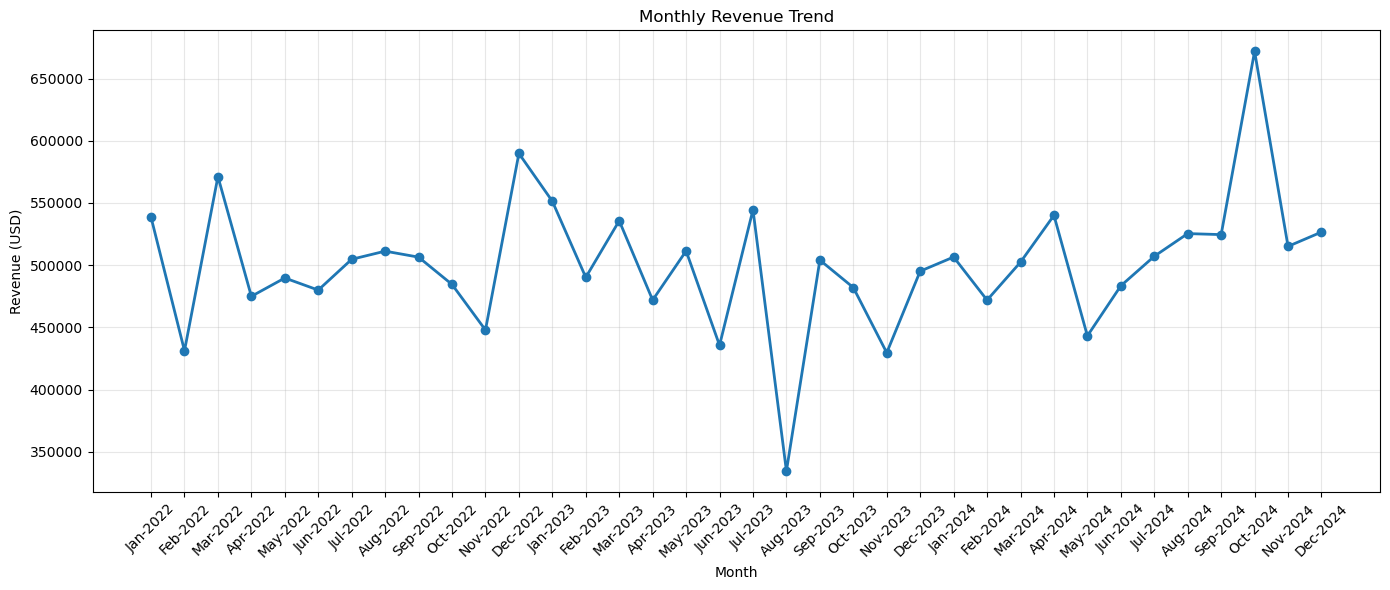

In [40]:
plt.figure(figsize=(14,6))

plt.plot(
    range(len(monthly_revenue)),
    monthly_revenue["revenue_usd"],
    marker="o",
    linewidth=2)

plt.xticks(
    range(len(monthly_revenue)),
    monthly_revenue["month"].str[:3] + "-" + monthly_revenue["year"].astype(str),
    rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

- Revenue remained relatively stable throughout the analysis period, generally ranging between **$430K and $590K** per month.
- A significant revenue peak was observed in **October 2024**, generating approximately **$672K**, indicating a period of exceptionally strong sales.
- The lowest monthly revenue occurred in **August 2023**, suggesting a temporary decline that may require further investigation.
- Revenue fluctuations indicate the presence of seasonal or market-driven factors, which will be explored further through quarterly, regional, and product-level analyses.

In [41]:
# Quarterly Revenue Analysis

quarterly_revenue = (
    df.groupby(["year", "quarter_number", "quarter"])["revenue_usd"]
      .sum()
      .reset_index()
      .sort_values(["year", "quarter_number"])
)
quarterly_revenue

,year,quarter_number,quarter,revenue_usd
0,2022,1,Q1,1540957.57
1,2022,2,Q2,1444731.45
2,2022,3,Q3,1522538.60
3,2022,4,Q4,1522296.88
4,2023,1,Q1,1577361.26
5,2023,2,Q2,1419065.37
6,2023,3,Q3,1383235.38
7,2023,4,Q4,1406942.87
8,2024,1,Q1,1480971.65
9,2024,2,Q2,1466729.13


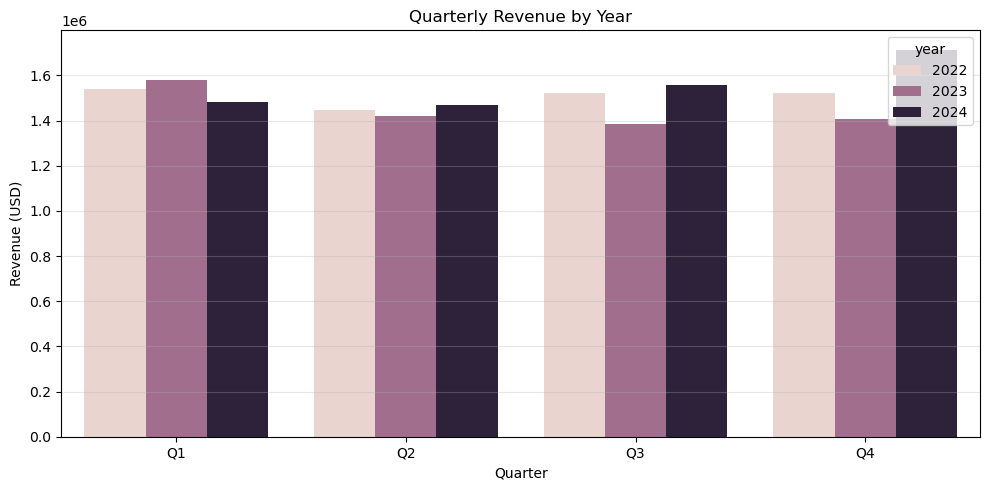

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=quarterly_revenue,
    x="quarter",
    y="revenue_usd",
    hue="year")

plt.title("Quarterly Revenue by Year")
plt.xlabel("Quarter")
plt.ylabel("Revenue (USD)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

- Revenue remained relatively consistent across quarters, indicating stable business performance throughout the three-year period.
- In 2022 and 2023, quarterly revenues showed only moderate fluctuations, with no single quarter consistently outperforming the others.
- Q4 of 2024 recorded the highest quarterly revenue (approximately **$1.71M**), suggesting a strong sales surge during the final quarter.
- Overall, the business does not exhibit a strong recurring seasonal pattern across all three years, although Q4 2024 stands out as an exceptional performance period that merits further investigation.

In [43]:
# Average Revenue by Quarter

quarter_avg = (
    df.groupby("quarter")["revenue_usd"]
      .mean()
      .reindex(["Q1", "Q2", "Q3", "Q4"])
      .reset_index()
)
quarter_avg

,quarter,revenue_usd
0,Q1,1589.250339
1,Q2,1535.647500
2,Q3,1558.292776
3,Q4,1588.946718


In [44]:
# Average Quarterly Revenue Across Years

quarter_avg = (
    quarterly_revenue
    .groupby("quarter")["revenue_usd"]
    .mean()
    .reindex(["Q1", "Q2", "Q3", "Q4"])
    .reset_index()
)

quarter_avg

,quarter,revenue_usd
0,Q1,1.533097e+06
1,Q2,1.443509e+06
2,Q3,1.487650e+06
3,Q4,1.547634e+06


In [45]:
# Revenue by Product Category

category_revenue = (
    df.groupby("category")["revenue_usd"]
      .sum()
      .sort_values(ascending=False)
      .reset_index())
category_revenue

,category,revenue_usd
0,Mac,8369961.42
1,iPhone,5734154.34
2,iPad,1829815.70
3,Apple Watch,958773.70
4,AirPods,572773.95
5,Accessories,570190.14


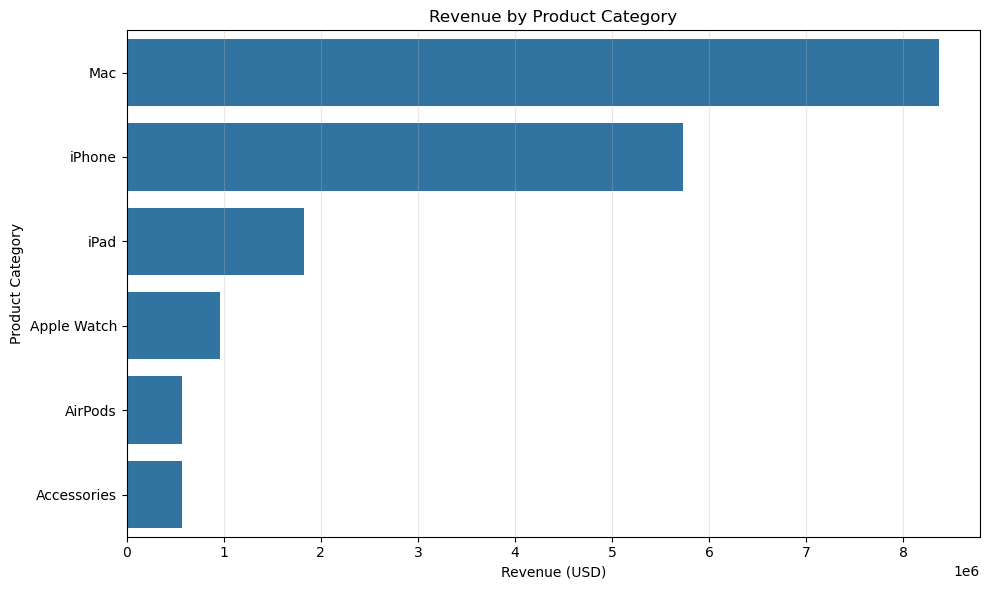

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_revenue,
    x="revenue_usd",
    y="category")

plt.title("Revenue by Product Category")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product Category")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Business Insight

- **Mac** is the highest revenue-generating product category, contributing approximately **\$8.37M**, making it the primary revenue driver.
- **iPhone** follows as the second-largest contributor with **\$5.73M**, highlighting its continued importance to Apple's overall sales.
- **iPad** contributes significantly less than Mac and iPhone, while **Apple Watch, AirPods, and Accessories** account for a relatively small share of total revenue.
- The revenue distribution suggests that Apple's sales are highly concentrated in its premium product categories.
  
### Business Recommendation

- Continue investing in Mac and iPhone product lines, as they contribute the majority of total revenue.
- Investigate opportunities to increase revenue from Apple Watch, AirPods, and Accessories through cross-selling, bundling, or targeted promotions.
- Analyze whether lower-performing categories have lower sales volumes, lower prices, or weaker customer demand before making pricing or marketing decisions.

In [47]:
# Units Sold by Product Category

category_units = (
    df.groupby("category")["units_sold"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
category_units

,category,units_sold
0,iPhone,6908
1,Accessories,5298
2,Mac,3789
3,iPad,2824
4,Apple Watch,2305
5,AirPods,2146


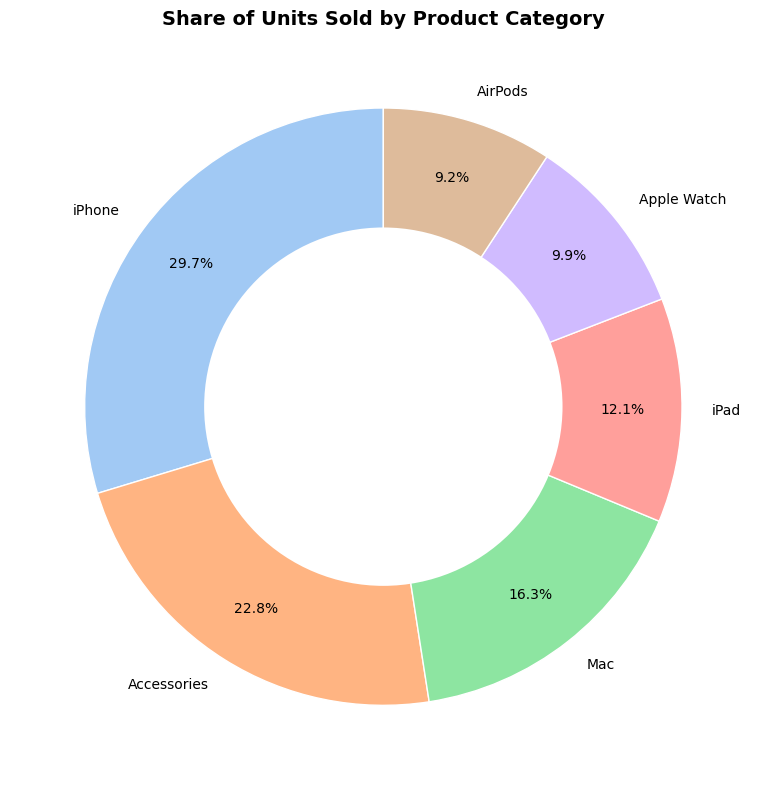

In [48]:
# Units Sold Share by Product Category

plt.figure(figsize=(8,8))

colors = sns.color_palette("pastel")

plt.pie(
    category_units["units_sold"],
    labels=category_units["category"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={"edgecolor": "white"}
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Share of Units Sold by Product Category", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

### Business Insight

- iPhone accounts for the largest share of total units sold, making it Apple's highest-volume product category.
- Accessories contribute the second-largest share of unit sales despite generating comparatively lower revenue, indicating a high-volume, low-price product strategy.
- Mac contributes a smaller share of units sold but remains the highest revenue-generating category, reflecting its premium pricing.
- Comparing unit share with revenue contribution highlights distinct pricing strategies across Apple's product portfolio.

In [49]:
# Revenue, Units Sold and Revenue per Unit

category_summary = (
    df.groupby("category")
      .agg(
          Revenue=("revenue_usd", "sum"),
          Units_Sold=("units_sold", "sum")
      )
      .reset_index()
)
category_summary["Revenue_per_Unit"] = (
    category_summary["Revenue"] / category_summary["Units_Sold"]
).round(2)

category_summary = category_summary.sort_values(
    by="Revenue_per_Unit",
    ascending=False
)
category_summary

,category,Revenue,Units_Sold,Revenue_per_Unit
3,Mac,8369961.42,3789,2209.02
5,iPhone,5734154.34,6908,830.07
4,iPad,1829815.70,2824,647.95
2,Apple Watch,958773.70,2305,415.95
1,AirPods,572773.95,2146,266.90
0,Accessories,570190.14,5298,107.62


In [50]:
print(f"Highest Revenue per Unit Category: {category_summary.iloc[0]['category']}")
print(f"Revenue per Unit: ${category_summary.iloc[0]['Revenue_per_Unit']:.2f}")

Highest Revenue per Unit Category: Mac
Revenue per Unit: $2209.02


In [51]:
# Revenue by Country

country_revenue = (
    df.groupby("country")
      .agg(
          Revenue=("revenue_usd", "sum"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values(by="Revenue", ascending=False)
      .reset_index()
)

country_revenue.head(10)

,country,Revenue,Units_Sold
0,Hong Kong,485261.23,530
1,Netherlands,455560.33,509
2,Mexico,454405.84,550
3,Canada,451801.06,537
4,Turkey,450007.23,533
5,Saudi Arabia,444411.63,494
6,Germany,444195.10,494
7,Japan,440942.04,576
8,Malaysia,432614.73,547
9,South Korea,429516.44,490


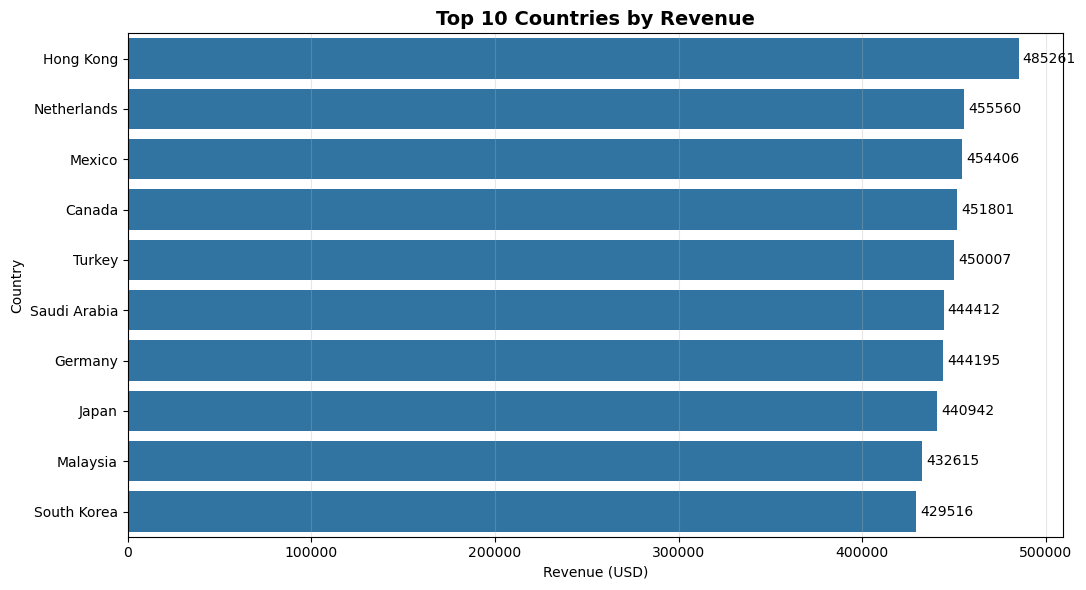

In [52]:
# Top 10 Countries by Revenue

top10_country = country_revenue.head(10)
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=top10_country,
    x="Revenue",
    y="country"
)

plt.title("Top 10 Countries by Revenue", fontsize=14, weight="bold")
plt.xlabel("Revenue (USD)")
plt.ylabel("Country")

# Add revenue labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Revenue per Unit by Country

country_summary = country_revenue.copy()

country_summary["Revenue_per_Unit"] = (
    country_summary["Revenue"] / country_summary["Units_Sold"]
).round(2)

country_summary = country_summary.sort_values(
    by="Revenue_per_Unit",
    ascending=False
)

country_summary.head(10)

,country,Revenue,Units_Sold,Revenue_per_Unit
0,Hong Kong,485261.23,530,915.59
18,Belgium,394390.36,431,915.06
17,India,394624.54,433,911.37
5,Saudi Arabia,444411.63,494,899.62
6,Germany,444195.10,494,899.18
1,Netherlands,455560.33,509,895.01
9,South Korea,429516.44,490,876.56
11,New Zealand,427616.89,489,874.47
21,Switzerland,387302.87,458,845.64
13,United Kingdom,412221.78,488,844.72


In [54]:
# Sales Channel Performance

channel_summary = (
    df.groupby("sales_channel")
      .agg(
          Revenue=("revenue_usd", "sum"),
          Units_Sold=("units_sold", "sum"),
          Average_Rating=("customer_rating", "mean"),
          Return_Rate=("return_flag", "mean")
      )
      .reset_index()
)

channel_summary["Return_Rate"] = (
    channel_summary["Return_Rate"] * 100
).round(2)

channel_summary = channel_summary.sort_values(
    by="Revenue",
    ascending=False
)

channel_summary

,sales_channel,Revenue,Units_Sold,Average_Rating,Return_Rate
2,Carrier Store,3189039.91,3960,3.992382,11.74
4,Online (Apple.com),3121857.55,3868,3.995745,11.96
0,Apple Store,2993323.16,3856,4.019037,11.60
5,Third-Party Retailer,2987135.57,3969,4.009382,11.58
3,Corporate / B2B,2901069.90,3736,3.985362,11.45
1,Authorized Reseller,2843243.16,3881,4.004142,12.47


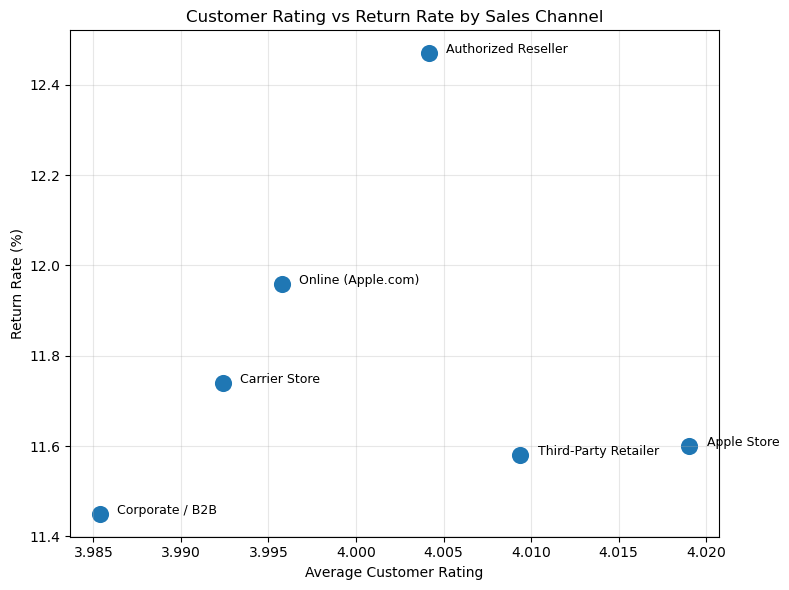

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=channel_summary,
    x="Average_Rating",
    y="Return_Rate",
    s=180
)

for i in range(len(channel_summary)):
    plt.text(
        channel_summary["Average_Rating"][i] + 0.001,
        channel_summary["Return_Rate"][i],
        channel_summary["sales_channel"][i],
        fontsize=9
    )

plt.title("Customer Rating vs Return Rate by Sales Channel")
plt.xlabel("Average Customer Rating")
plt.ylabel("Return Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# Create Discount Buckets

df["discount_bucket"] = pd.cut(
    df["discount_pct"],
    bins=[-1, 0, 10, 20, 30],
    labels=["0%", "1-10%", "11-20%", "21-30%"]
)

df["discount_bucket"].value_counts().sort_index()

discount_bucket
0%        5226
1-10%     5237
11-20%    1037
21-30%       0
Name: count, dtype: int64

In [61]:
# Average Units Sold by Discount Bucket

discount_analysis = (
    df.groupby("discount_bucket", observed=True)
      .agg(
          Average_Units_Sold=("units_sold", "mean"),
          Average_Revenue=("revenue_usd", "mean"),
          Transactions=("sale_id", "count")
      )
      .reset_index()
)

# Remove empty discount buckets
discount_analysis = discount_analysis[discount_analysis["Transactions"] > 0]

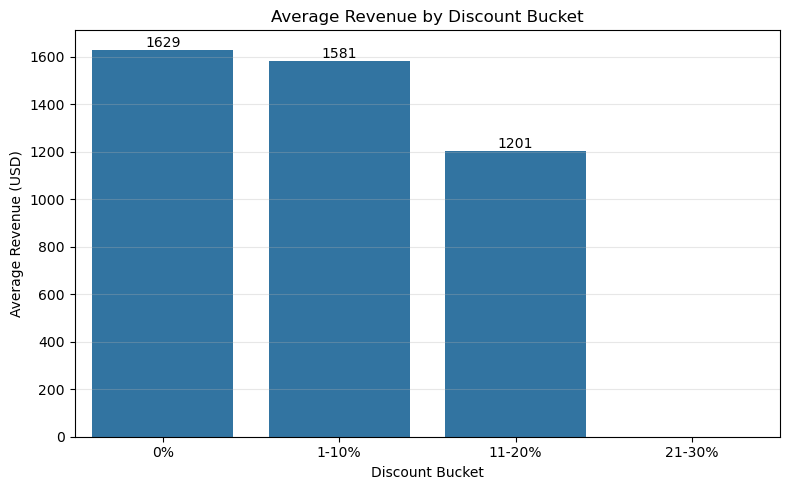

In [62]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=discount_analysis,
    x="discount_bucket",
    y="Average_Revenue"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Average Revenue by Discount Bucket")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Revenue (USD)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
# Customer Segment Performance

segment_summary = (
    df.groupby("customer_segment")
      .agg(
          Revenue=("revenue_usd", "sum"),
          Units_Sold=("units_sold", "sum"),
          Average_Rating=("customer_rating", "mean"),
          Return_Rate=("return_flag", "mean")
      )
      .reset_index()
)

segment_summary["Return_Rate"] = (
    segment_summary["Return_Rate"] * 100
).round(2)

segment_summary = segment_summary.sort_values(
    by="Revenue",
    ascending=False
)

segment_summary

,customer_segment,Revenue,Units_Sold,Average_Rating,Return_Rate
1,Education,4635788.76,5760,4.007342,12.52
2,Government,4493435.53,5882,3.992654,10.75
0,Business,4455761.84,5771,4.005055,12.12
3,Individual,4450683.12,5857,3.998724,11.82


In [64]:
# Product Preference by Age Group

age_category = (
    df.pivot_table(
        index="customer_age_group",
        columns="category",
        values="units_sold",
        aggfunc="sum"
    )
)

age_category

category,Accessories,AirPods,Apple Watch,Mac,iPad,iPhone
customer_age_group,,,,,,
18–24,1076,408,473,721,560,1468
25–34,1047,455,473,785,560,1382
35–44,1037,438,393,760,565,1332
45–54,1089,428,462,757,614,1375
55+,1049,417,504,766,525,1351


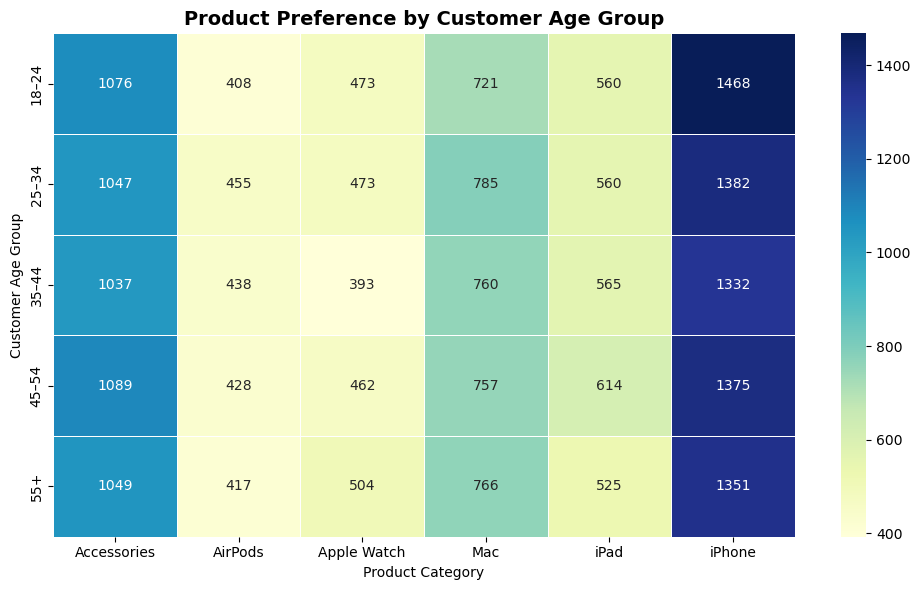

In [68]:
# Product Preference by Age Group

plt.figure(figsize=(10,6))

sns.heatmap(
    age_category,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Product Preference by Customer Age Group", fontsize=14,
          weight="bold")
plt.xlabel("Product Category")
plt.ylabel("Customer Age Group")

plt.tight_layout()
plt.show()

In [69]:
# Return Rate by Product Category

return_analysis = (
    df.groupby("category")
      .agg(
          Total_Orders=("sale_id", "count"),
          Returned_Orders=("return_flag", "sum")
      )
      .reset_index()
)

return_analysis["Return_Rate"] = (
    return_analysis["Returned_Orders"] /
    return_analysis["Total_Orders"] * 100
).round(2)

return_analysis = return_analysis.sort_values(
    by="Return_Rate",
    ascending=False
)

return_analysis

,category,Total_Orders,Returned_Orders,Return_Rate
3,Mac,1873,234,12.49
4,iPad,1379,169,12.26
1,AirPods,1063,130,12.23
5,iPhone,3444,414,12.02
2,Apple Watch,1126,127,11.28
0,Accessories,2615,283,10.82


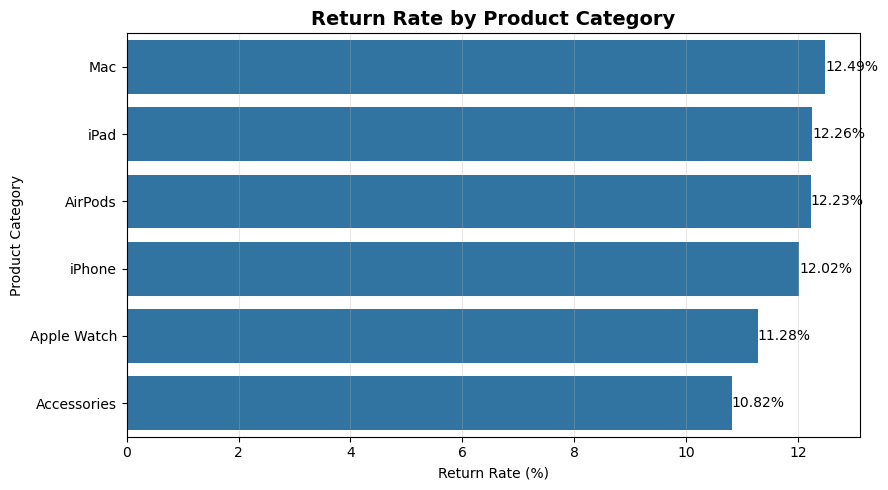

In [70]:
# Return Rate by Product Category

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=return_analysis,
    x="Return_Rate",
    y="category"
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Return Rate by Product Category", fontsize=14, weight="bold")
plt.xlabel("Return Rate (%)")
plt.ylabel("Product Category")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
# Select numerical columns

corr_columns = [
    "unit_price_usd",
    "discount_pct",
    "units_sold",
    "discounted_price_usd",
    "revenue_usd",
    "customer_rating",
    "return_flag"
]

correlation = df[corr_columns].corr()

correlation.round(2)

,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,customer_rating,return_flag
unit_price_usd,1.00,-0.01,-0.00,1.00,0.76,0.00,0.01
discount_pct,-0.01,1.00,-0.01,-0.04,-0.04,0.01,0.00
units_sold,-0.00,-0.01,1.00,-0.00,0.38,0.00,0.01
discounted_price_usd,1.00,-0.04,-0.00,1.00,0.76,0.00,0.01
revenue_usd,0.76,-0.04,0.38,0.76,1.00,0.00,0.01
customer_rating,0.00,0.01,0.00,0.00,0.00,1.00,0.01
return_flag,0.01,0.00,0.01,0.01,0.01,0.01,1.00


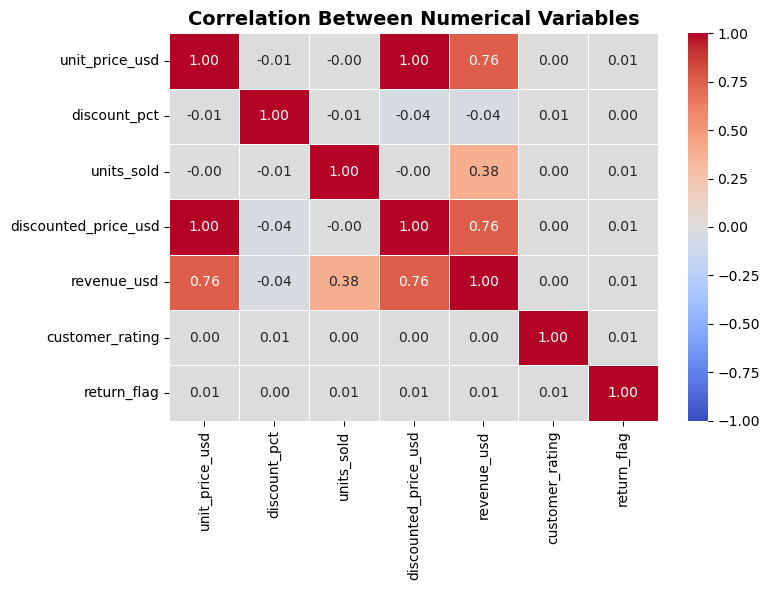

In [72]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Variables",
          fontsize=14,
          weight="bold")

plt.tight_layout()
plt.show()

# Statistical Hypothesis Testing

Exploratory Data Analysis helps identify patterns in the data. However, these patterns may occur by chance. Statistical hypothesis testing is used to validate whether the observed differences are statistically significant.

This section applies basic statistical tests to support business decisions using data.

In [73]:
from scipy.stats import f_oneway

## Does Discount Affect Revenue?

### Business Question

Does offering different discount levels significantly change the average revenue generated per transaction?

### Test Used

One-Way ANOVA

### Why ANOVA?

The dataset contains three discount groups (0%, 1–10%, and 11–20%). ANOVA is suitable for comparing the average revenue across more than two groups.

# Revenue grouped by discount bucket

discount_groups = []

for bucket in df["discount_bucket"].dropna().unique():
    revenue = df[df["discount_bucket"] == bucket]["revenue_usd"]
    discount_groups.append(revenue)

# Perform One-Way ANOVA

f_stat, p_value = f_oneway(*discount_groups)

print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

### Conclusion

Since the p-value is less than 0.05, the null hypothesis is rejected.
There is a statistically significant difference in average revenue across different discount levels. This supports the earlier observation that increasing discounts is associated with lower average revenue.

## Do Customer Segments Generate Different Revenue?

### Business Question

Do different customer segments contribute significantly different average revenue per transaction?

### Test Used

One-Way ANOVA

In [76]:
# Revenue grouped by customer segment

segment_groups = []

for segment in df["customer_segment"].unique():
    revenue = df[df["customer_segment"] == segment]["revenue_usd"]
    segment_groups.append(revenue)

# Perform ANOVA

f_stat, p_value = f_oneway(*segment_groups)

print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

F-statistic: 0.286
P-value: 0.8355513665589877


### Conclusion

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

There is no statistically significant difference in average revenue across customer segments. This suggests that all customer segments contribute similarly in terms of average revenue per transaction.

## Is Return Status Associated with Product Category?

### Business Question

Does the likelihood of a product being returned depend on its product category?

### Test Used

Chi-Square Test of Independence

In [78]:
from scipy.stats import chi2_contingency

# Create contingency table

contingency_table = pd.crosstab(
    df["category"],
    df["return_status"]
)

contingency_table

return_status,Exchanged,Kept,Returned
category,,,
Accessories,93,2332,190
AirPods,43,933,87
Apple Watch,50,999,77
Mac,86,1639,148
iPad,53,1210,116
iPhone,134,3030,280


In [79]:
from scipy.stats import chi2_contingency

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", round(chi2, 3))
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

Chi-Square Statistic: 7.819
Degrees of Freedom: 10
P-value: 0.6464687298195908


### Conclusion

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

There is no statistically significant association between product category and return status. The observed differences in return rates across product categories are likely due to random variation rather than the product category itself.

In [81]:
df.drop(columns=["calculated_revenue"], inplace=True, errors="ignore")

In [82]:
df.to_csv("apple_global_sales_cleaned.csv", index=False)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   sale_id                 11500 non-null  object        
 1   sale_date               11500 non-null  datetime64[ns]
 2   year                    11500 non-null  int64         
 3   quarter                 11500 non-null  object        
 4   month                   11500 non-null  object        
 5   country                 11500 non-null  object        
 6   region                  11500 non-null  object        
 7   city                    11500 non-null  object        
 8   product_name            11500 non-null  object        
 9   category                11500 non-null  object        
 10  storage                 11500 non-null  object        
 11  color                   11500 non-null  object        
 12  unit_price_usd          11500 non-null  float6

# Next Phase

The cleaned dataset generated from this notebook will be used for:

• SQL Business Analysis

• Interactive Power BI Dashboard

• AI-powered Business Insight Generation